# Continuous Lloyd Flow Between Gaussian Mixtures

This notebook generates `fig:semidiscrete-lloyd-flow-mixtures`.  It illustrates the relaxed Lloyd dynamics
$$
    y_j^{(k+1)} = y_j^{(k)} + \tau\big(b_j(Y^{(k)})-y_j^{(k)}\big)
$$
as an explicit-Euler discretization of the configuration-space gradient flow of the quadratic quantization energy.  The initial codepoints are sampled from a source Gaussian mixture, while the Voronoi centroids are computed with respect to a different target Gaussian-mixture density.

In [1]:
from pathlib import Path
import shutil
import sys

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_rgb

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, GRAY, LIGHT_GRAY, DIRAC_MARKER_SIZE,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, box_axes,
    interp_color,
)

setup_matplotlib()

NAME = "semidiscrete-lloyd-flow-mixtures"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
ARXIV = ROOT / "arxiv" / "figures"
ARXIV.mkdir(parents=True, exist_ok=True)
THUMB.parent.mkdir(parents=True, exist_ok=True)

## Source and target mixtures

The target mixture defines the continuous measure \(\alpha\) entering the quantization energy.  The red source mixture is only used to initialize the labelled codepoints away from the blue target density.

In [2]:
rng = np.random.default_rng(4059)

xlim = (-2.05, 2.20)
ylim = (-1.55, 1.55)
gx = np.linspace(*xlim, 250)
gy = np.linspace(*ylim, 190)
GX, GY = np.meshgrid(gx, gy)
flat = np.column_stack([GX.ravel(), GY.ravel()])
dx = gx[1] - gx[0]
dy = gy[1] - gy[0]

source_means = np.array([
    [-1.22, -0.52],
    [-1.05,  0.58],
    [-0.35,  0.02],
])
source_covs = np.array([
    [[0.090,  0.020], [ 0.020, 0.070]],
    [[0.075, -0.014], [-0.014, 0.105]],
    [[0.055,  0.012], [ 0.012, 0.055]],
])
source_weights = np.array([0.42, 0.34, 0.24])

target_means = np.array([
    [0.36,  0.58],
    [1.08, -0.08],
    [0.42, -0.76],
])
target_covs = np.array([
    [[0.165, -0.038], [-0.038, 0.105]],
    [[0.180,  0.040], [ 0.040, 0.145]],
    [[0.095, -0.010], [-0.010, 0.070]],
])
target_weights = np.array([0.36, 0.43, 0.21])


def gaussian_density(points, mean, cov):
    diff = points - mean[None, :]
    inv = np.linalg.inv(cov)
    quad = np.einsum("ni,ij,nj->n", diff, inv, diff)
    return np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(np.linalg.det(cov)))


def mixture_density(points, means, covs, weights):
    rho = np.zeros(len(points))
    for w, m, c in zip(weights, means, covs):
        rho += w * gaussian_density(points, m, c)
    return rho

rho_target = mixture_density(flat, target_means, target_covs, target_weights).reshape(GX.shape)
rho_target /= rho_target.sum() * dx * dy
quad_weights = rho_target.ravel() * dx * dy

target_levels = np.quantile(rho_target[rho_target > np.quantile(rho_target, 0.55)], [0.38, 0.56, 0.72, 0.86, 0.95])
target_cmap = LinearSegmentedColormap.from_list("target_blue", ["#ffffff", "#edf4fb", "#7eb3d9", BLUE])

## Relaxed Lloyd dynamics

Each step recomputes the Voronoi diagram of the moving sites on the quadrature grid, evaluates the target-density centroids of the cells, and moves only a fraction \(\tau\) toward those centroids.  The stored energy is the grid approximation of
$$
    \mathcal F(Y)=\int \min_j \|x-y_j\|^2\,d\alpha(x).
$$

In [3]:
def sample_mixture(rng, means, covs, weights, n):
    labels = rng.choice(len(weights), size=n, p=weights / weights.sum())
    out = np.empty((n, 2))
    for k in range(len(weights)):
        idx = np.flatnonzero(labels == k)
        if len(idx):
            out[idx] = rng.multivariate_normal(means[k], covs[k], size=len(idx))
    return out

m = 64
centers = sample_mixture(rng, source_means, source_covs, source_weights, m)
centers[:, 0] = np.clip(centers[:, 0], xlim[0] + 0.20, xlim[1] - 0.20)
centers[:, 1] = np.clip(centers[:, 1], ylim[0] + 0.16, ylim[1] - 0.16)
centers = centers[np.argsort(centers[:, 0] + 0.15 * centers[:, 1])]

n_steps = 240
tau = 0.085
snapshot_ids = [0, 24, 80, 240]
trajectories = [centers.copy()]
energies = []

for k in range(n_steps + 1):
    diff = flat[:, None, :] - centers[None, :, :]
    dist2 = np.sum(diff * diff, axis=2)
    labels = np.argmin(dist2, axis=1)
    energies.append(float(np.dot(quad_weights, dist2[np.arange(len(flat)), labels])))

    if k == n_steps:
        break

    masses = np.bincount(labels, weights=quad_weights, minlength=m)
    sx = np.bincount(labels, weights=quad_weights * flat[:, 0], minlength=m)
    sy = np.bincount(labels, weights=quad_weights * flat[:, 1], minlength=m)
    centroids = centers.copy()
    nonempty = masses > 1e-12
    centroids[nonempty, 0] = sx[nonempty] / masses[nonempty]
    centroids[nonempty, 1] = sy[nonempty] / masses[nonempty]
    centers = centers + tau * (centroids - centers)
    trajectories.append(centers.copy())

trajectories = np.stack(trajectories, axis=0)
energies = np.asarray(energies)
relative_energy = energies / max(energies[0], 1e-15)
print(f"initial energy = {energies[0]:.5f}, final energy = {energies[-1]:.5f}")

initial energy = 0.73099, final energy = 0.02899


## Exported panels

The snapshots show the same target density in blue, with contours and shading, while the moving disks and short trajectories reveal the relaxed finite-dimensional flow.  The separate curve reports the monotone decay of the relative quantization energy.

In [4]:
def add_density_background(ax):
    vmax = np.quantile(rho_target, 0.985)
    image = np.clip(rho_target, 0, vmax) / vmax
    ax.imshow(
        image,
        origin="lower",
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        cmap=target_cmap,
        alpha=0.50,
        interpolation="bilinear",
        zorder=0,
    )
    ax.contour(GX, GY, rho_target, levels=target_levels, colors=[BLUE], linewidths=0.68, alpha=0.70, zorder=2)


def add_trajectories(ax, k, *, alpha=0.22, linewidth=0.52):
    if k <= 1:
        return
    step = max(1, k // 34)
    segments = []
    colors = []
    for j in range(m):
        pts = trajectories[: k + 1 : step, j, :]
        if len(pts) < 2:
            continue
        segs = np.stack([pts[:-1], pts[1:]], axis=1)
        segments.extend(segs)
        for r in np.linspace(0, k / n_steps, len(segs)):
            colors.append((*interp_color(r, RED, BLUE), alpha))
    lc = LineCollection(segments, colors=colors, linewidths=linewidth, zorder=3, capstyle="round")
    ax.add_collection(lc)


def finish_snapshot(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)


def plot_snapshot(ax, k):
    add_density_background(ax)
    add_trajectories(ax, k)
    color = interp_color(k / n_steps, RED, BLUE)
    ax.scatter(
        trajectories[k, :, 0], trajectories[k, :, 1],
        s=DIRAC_MARKER_SIZE * 0.52,
        marker="o", color=color, edgecolor="white", linewidth=0.20, zorder=5,
    )
    finish_snapshot(ax)


def plot_energy(ax):
    it = np.arange(n_steps + 1)
    ax.plot(it, relative_energy, color=VIOLET, linewidth=1.75, zorder=2)
    for k in snapshot_ids:
        ax.scatter([k], [relative_energy[k]], s=18, color=interp_color(k / n_steps, RED, BLUE), edgecolor="white", linewidth=0.35, zorder=4)
    ax.set_xlim(0, n_steps)
    ax.set_ylim(0.0, 1.04)
    ax.set_xticks([0, 80, 160, 240])
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xlabel(r"iteration $k$", labelpad=1)
    ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=7, pad=1.5)
    ax.grid(True, color=LIGHT_GRAY, linewidth=0.35, alpha=0.72)
    box_axes(ax)

# Clean stale panels so old snapshot filenames are not kept after changing the time horizon.
for pdf in OUT.glob("*.pdf"):
    pdf.unlink()
for pdf in ARXIV.glob(f"{NAME}--*.pdf"):
    pdf.unlink()

for k in snapshot_ids:
    fig, ax = plt.subplots(figsize=(2.12, 1.68))
    plot_snapshot(ax, k)
    save_pdf(fig, OUT / f"snapshot-{k:03d}.pdf", pad_inches=0.025)
    plt.close(fig)

fig, ax = plt.subplots(figsize=(2.38, 1.68))
plot_energy(ax)
save_pdf(fig, OUT / "energy-decay.pdf", pad_inches=0.025)
plt.close(fig)

# A compact raster overview is used only as the notebook/gallery thumbnail.
fig = plt.figure(figsize=(9.9, 1.82))
grid = fig.add_gridspec(1, 5, width_ratios=[1, 1, 1, 1, 1.28], wspace=0.065)
for col, k in enumerate(snapshot_ids):
    ax = fig.add_subplot(grid[0, col])
    plot_snapshot(ax, k)
    ax.text(0.04, 0.94, rf"$k={k}$", transform=ax.transAxes, ha="left", va="top", color=GRAY, fontsize=8, bbox=dict(facecolor="white", edgecolor="none", alpha=0.72, pad=1.2))
ax = fig.add_subplot(grid[0, 4])
plot_energy(ax)
fig.savefig(THUMB, dpi=185, bbox_inches="tight", pad_inches=0.035)
plt.close(fig)

for pdf in sorted(OUT.glob("*.pdf")):
    shutil.copy2(pdf, ARXIV / f"{NAME}--{pdf.name}")

print(f"Saved {len(list(OUT.glob('*.pdf')))} PDFs in {OUT.relative_to(ROOT)}")
print(f"Saved thumbnail {THUMB.relative_to(ROOT)}")

'created' timestamp seems very low; regarding as unix timestamp


'modified' timestamp seems very low; regarding as unix timestamp


Saved 5 PDFs in OT4ML/figures/semidiscrete-lloyd-flow-mixtures
Saved thumbnail notebooks-figures/thumbnails/semidiscrete-lloyd-flow-mixtures.png


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.

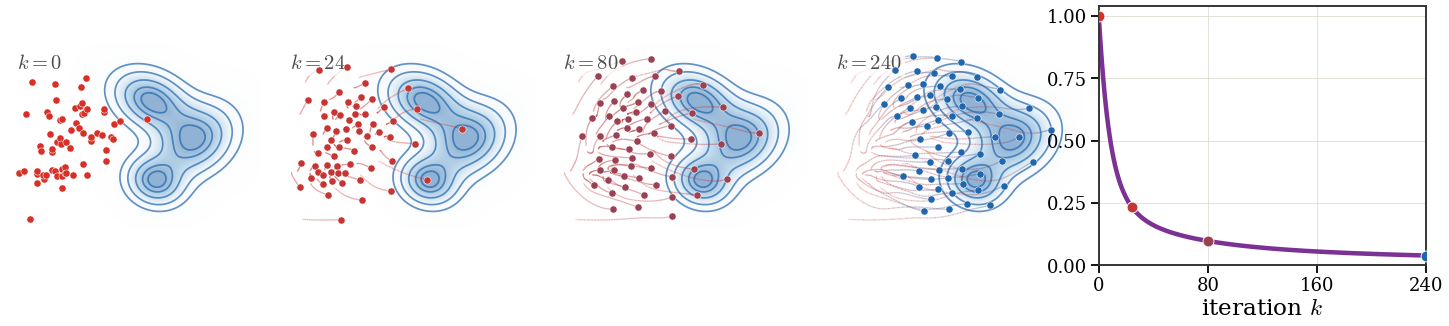

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/semidiscrete-lloyd-flow-mixtures.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/semidiscrete-lloyd-flow-mixtures.png")
display(Image(filename=str(_thumb)))